# EJERCICIO : COMPARAR MODELOS DE REGRESION PARA ESTE DATASET USED CARS
## DATASET https://www.kaggle.com/datasets/alemazz11/cars-europe

# PASO 1 - INSTALAMOS E IMPORTAMOS LIBRERIAS

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
sns.set(style='whitegrid',context='notebook')

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("alemazz11/cars-europe")

print("Path to dataset files:", path)

100%|██████████| 2.64M/2.64M [00:00<00:00, 3.09MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/alemazz11/cars-europe/versions/1


In [4]:
!ls /root/.cache/kagglehub/datasets/alemazz11/cars-europe/versions/1

fullGas.csv


In [5]:
PATH_CSV = path + '/fullGas.csv'

In [7]:
%run '/content/pandas_missing_extension.ipynb'

In [44]:
df = pd.read_csv(PATH_CSV)
df

,Make,Model,Body,Mileage_km,Price,Year,Country,Condition,Fuel_Type,Fuel_Consumption_l,...,Cylinders,Seats,Doors,Color,Upholstery,Full_Service_History,Non_Smoker_Vehicle,Previous_Owners,Seller,Image_url
0,Abarth,595,Compact,98000,16900,2020.0,IT,Used,Gasoline,6.7,...,4.0,4.0,3.0,White,Full leather,False,False,NaN,Dealer,https://prod.pictures.autoscout24.net/listing-...
1,Abarth,595,Sedan,91500,12500,2017.0,IT,Used,Gasoline,6.0,...,4.0,4.0,3.0,Grey,Full leather,False,True,4.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
2,Abarth,595,Compact,40000,17990,2015.0,IT,Used,Gasoline,6.5,...,4.0,4.0,3.0,Bronze,Full leather,True,True,1.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
3,Abarth,500,Compact,133000,9300,2008.0,IT,Used,Gasoline,6.5,...,4.0,4.0,3.0,Black,Cloth,True,True,2.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
4,Abarth,595,Compact,61019,14990,2021.0,BE,Used,Gasoline,NaN,...,4.0,4.0,3.0,Yellow,Part leather,True,True,1.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40489,Volvo,V60 Cross Country,Station wagon,73627,32990,2023.0,DE,Used,Diesel,NaN,...,NaN,5.0,5.0,Grey,Part leather,True,True,1.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
40490,Volvo,XC60,Off-Road/Pick-up,93671,26990,2020.0,IT,Used,Electric/Diesel,NaN,...,4.0,5.0,5.0,Grey,Cloth,False,False,NaN,Dealer,https://prod.pictures.autoscout24.net/listing-...
40491,Volvo,V90,Station wagon,60200,32490,2020.0,DE,Used,Gasoline,NaN,...,4.0,5.0,5.0,Black,Full leather,True,True,2.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
40492,Volvo,XC40,Off-Road/Pick-up,49088,29450,2022.0,NL,Used,Electric/Gasoline,NaN,...,3.0,5.0,5.0,Black,Cloth,True,False,NaN,Dealer,https://prod.pictures.autoscout24.net/listing-...


In [62]:
df['Make'].value_counts()

,count
Make,
Bentley,958
Citroen,942
Alfa Romeo,940
Jeep,931
Mazda,931
Jaguar,930
Aston Martin,927
Volvo,926
Toyota,924


In [9]:
df.missing.number_missing()

np.int64(103838)

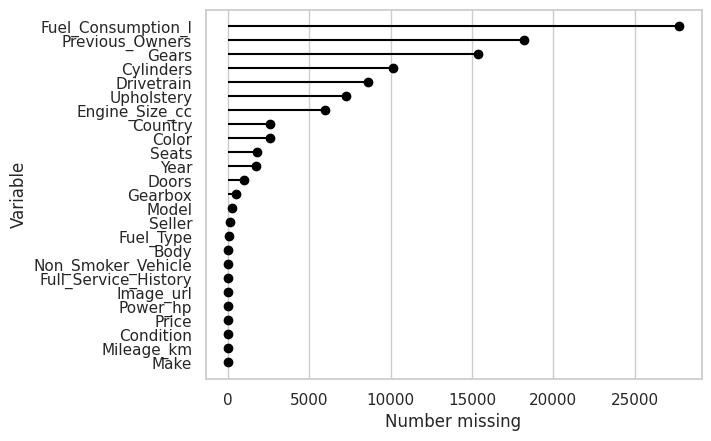

In [10]:
df.missing.missing_variable_plot()

# IMPUTACIÓN DE VARIABLES NÚMERICAS

In [45]:
numerics_nan = ['Fuel_Consumption_l','Previous_Owners','Gears','Cylinders','Engine_Size_cc','Seats','Year','Doors']

In [46]:
df_cleaned = df.copy()

In [47]:
for variable in numerics_nan:
  df_cleaned[variable] = df_cleaned[variable].fillna(float(round(df_cleaned[variable].mean())))

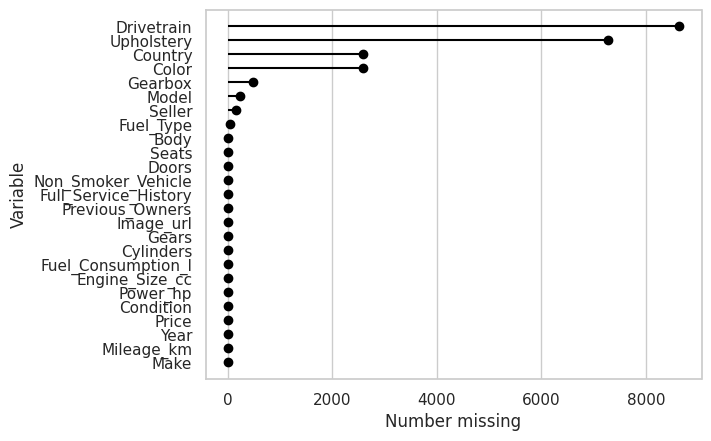

In [48]:
df_cleaned.missing.missing_variable_plot()

# IMPUTACIÓN DE VARIABLES CATEGORICAS

In [49]:
objects_nan = ['Fuel_Type','Body','Drivetrain','Upholstery','Country','Color','Gearbox','Model','Seller']

In [50]:
for variable in objects_nan:
  df_cleaned[variable] = df_cleaned[variable].ffill()
  df_cleaned[variable] = df_cleaned[variable].bfill()

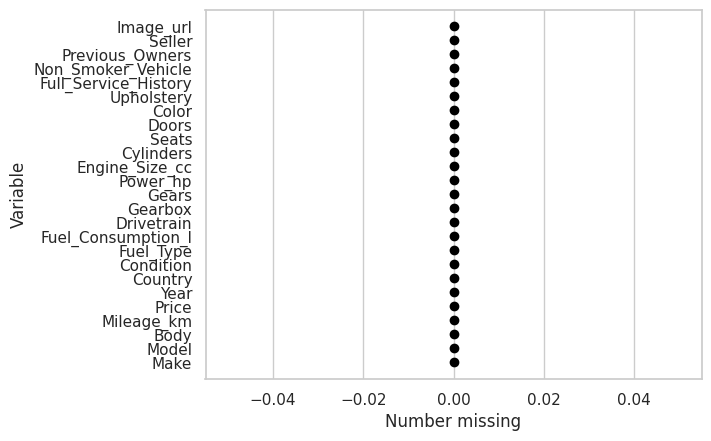

In [51]:
df_cleaned.missing.missing_variable_plot()

In [52]:
df_cleaned.missing.number_missing()

np.int64(0)

In [53]:
df_cleaned['Condition'].value_counts()

,count
Condition,
Used,38701
New,1793


In [243]:
df_cleaned.shape

(7311, 25)

In [55]:
df_cleaned = df_cleaned[df_cleaned['Condition'] == 'Used']
df_cleaned.shape

(38701, 25)

# DATOS ATIPICOS

In [56]:
df_cleaned.describe()

,Mileage_km,Price,Year,Fuel_Consumption_l,Gears,Power_hp,Engine_Size_cc,Cylinders,Seats,Doors,Previous_Owners
count,3.870100e+04,3.870100e+04,38701.000000,38701.000000,38701.000000,38701.000000,38701.000000,38701.000000,38701.000000,38701.000000,38701.000000
mean,8.080787e+04,5.291525e+04,2017.403736,6.909173,5.949691,227.627348,2257.567065,4.776698,4.652360,4.244231,1.241828
std,3.285581e+05,1.723684e+05,9.144381,2.028039,1.557685,175.954474,1409.471845,1.907623,1.637645,1.101509,0.797472
min,0.000000e+00,1.000000e+00,1922.000000,0.100000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000
25%,2.100000e+04,1.300000e+04,2015.000000,7.000000,6.000000,116.000000,1390.000000,4.000000,5.000000,4.000000,1.000000
50%,5.975300e+04,2.169000e+04,2020.000000,7.000000,6.000000,156.000000,1984.000000,4.000000,5.000000,5.000000,1.000000
75%,1.093300e+05,3.499000e+04,2023.000000,7.000000,6.000000,275.000000,2275.000000,5.000000,5.000000,5.000000,1.000000
max,1.677722e+07,9.999999e+06,2026.000000,55.000000,69.000000,3399.000000,67500.000000,50.000000,255.000000,25.000000,94.000000


In [232]:
variable = 'Previous_Owners'
data = df_cleaned[variable]

In [239]:
mean_val = data.mean()
median_val = data.median()
mode_val = data.mode()[0]

print(f"📊 Medidas de tendencia central de {variable}")
print(f"Media (μ): {mean_val:.2f}")
print(f"Mediana: {median_val:.2f}")
print(f"Moda: {mode_val:.2f}")

📊 Medidas de tendencia central de Previous_Owners
Media (μ): 1.00
Mediana: 1.00
Moda: 1.00


In [240]:
variance_val = data.var()
std_val = data.std()
range_val = data.max() - data.min()
q1 = data.quantile(0.25)
q3 = data.quantile(0.75)
iqr = q3 - q1
print(f"\n📈 Medidas de dispersión de {variable}")
print(f"Varianza (σ²): {variance_val:.2f}")
print(f"Desviación estándar (σ): {std_val:.2f}")
print(f"Rango: {range_val:.2f}")
print(f"Rango intercuartílico (IQR): {iqr:.2f}")


📈 Medidas de dispersión de Previous_Owners
Varianza (σ²): 0.00
Desviación estándar (σ): 0.00
Rango: 0.00
Rango intercuartílico (IQR): 0.00


In [242]:
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

outliers = data[(data < limite_inferior) | (data > limite_superior)]

print(f"\n⚠️ Detección de Outliers (Regla del IQR) para {variable}")
print(f"Límite inferior: {limite_inferior:.2f}")
print(f"Límite superior: {limite_superior:.2f}")
print(f"Número de outliers detectados: {len(outliers)}")


⚠️ Detección de Outliers (Regla del IQR) para Previous_Owners
Límite inferior: 1.00
Límite superior: 1.00
Número de outliers detectados: 0


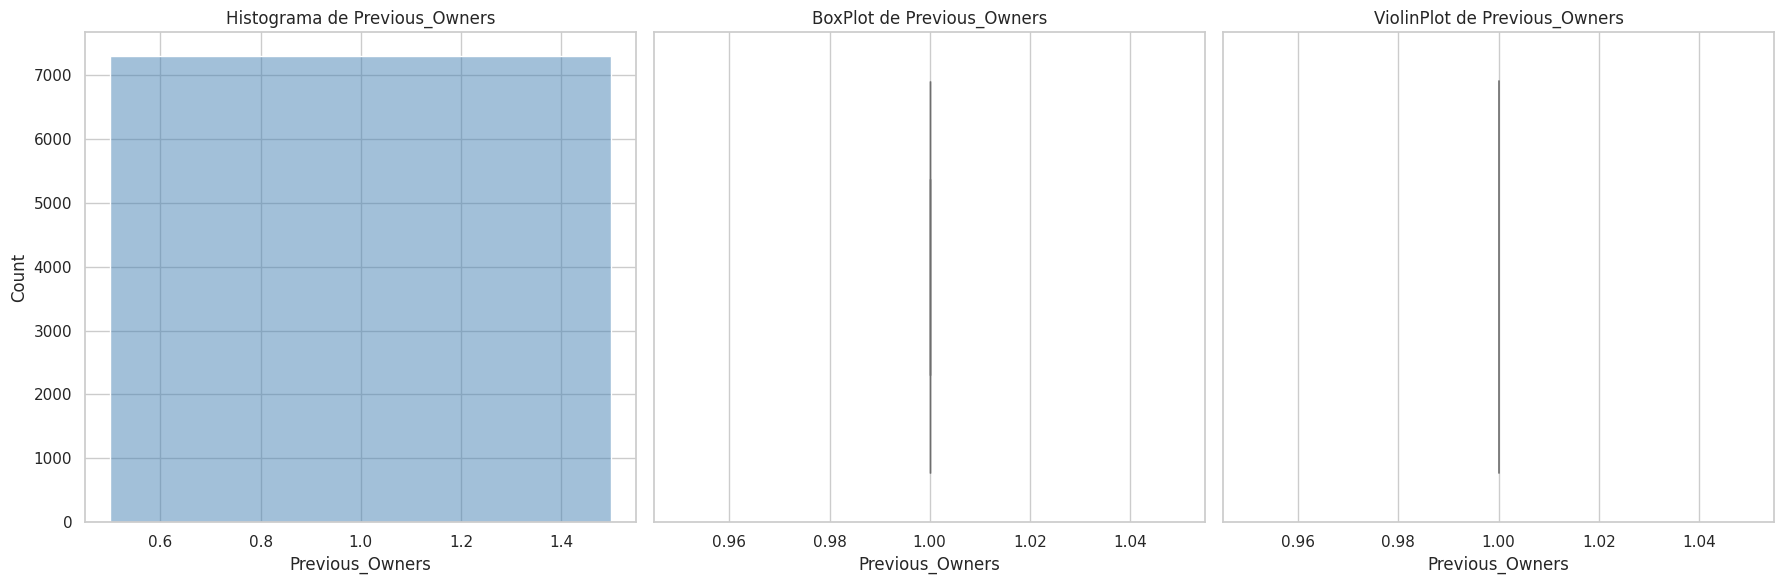

In [241]:
fig,axes = plt.subplots(1,3,figsize=(18,6))

#histograma
sns.histplot(data,kde=True,color='steelblue',ax=axes[0])
axes[0].set_title(f'Histograma de {variable}')

#boxplot
sns.boxplot(x=data,color='lightcoral',ax=axes[1])
axes[1].set_title(f'BoxPlot de {variable}')

#violinplot
sns.violinplot(x=data,color='lightgreen',ax=axes[2])
axes[2].set_title(f'ViolinPlot de {variable}')

plt.tight_layout()
plt.show()

# ELIMINAR OUTLIERS

In [237]:
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

In [238]:
df_cleaned = remove_outliers(df_cleaned,variable)
data = df_cleaned[variable]

In [244]:
df_cleaned.columns

Index(['Make', 'Model', 'Body', 'Mileage_km', 'Price', 'Year', 'Country',
       'Condition', 'Fuel_Type', 'Fuel_Consumption_l', 'Drivetrain', 'Gearbox',
       'Gears', 'Power_hp', 'Engine_Size_cc', 'Cylinders', 'Seats', 'Doors',
       'Color', 'Upholstery', 'Full_Service_History', 'Non_Smoker_Vehicle',
       'Previous_Owners', 'Seller', 'Image_url'],
      dtype='object')

In [245]:
df_encoded = df_cleaned[['Mileage_km', 'Price', 'Year', 'Fuel_Type', 'Gearbox',
       'Gears', 'Power_hp', 'Engine_Size_cc', 'Cylinders', 'Seats', 'Doors']].copy()

In [246]:
df_encoded

,Mileage_km,Price,Year,Fuel_Type,Gearbox,Gears,Power_hp,Engine_Size_cc,Cylinders,Seats,Doors
66,30000,17300,2022.0,Gasoline,Manual,6.0,145,1398.0,5.0,5.0,4.0
151,14574,21900,2020.0,Gasoline,Manual,6.0,145,1368.0,5.0,5.0,4.0
171,138597,8990,2009.0,Gasoline,Manual,6.0,136,2275.0,5.0,5.0,3.0
182,46500,17990,2019.0,Gasoline,Manual,6.0,166,2275.0,5.0,5.0,3.0
211,595,32950,2025.0,Electric,Automatic,6.0,237,2275.0,5.0,5.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...
40454,35295,31950,2023.0,Electric,Automatic,6.0,231,2275.0,5.0,5.0,5.0
40460,141565,13450,2015.0,Gasoline,Automatic,6.0,150,1596.0,4.0,5.0,5.0
40471,93769,22900,2020.0,Diesel,Automatic,6.0,190,2275.0,5.0,5.0,4.0
40475,87055,22090,2021.0,Electric/Gasoline,Automatic,6.0,212,2275.0,5.0,5.0,5.0


# CODIFICACIÓN DE VARIABLES CATEGORICAS CON SKLEARN

In [247]:
categorical_columns = df_encoded.select_dtypes(object).columns
categorical_columns

Index(['Fuel_Type', 'Gearbox'], dtype='object')

In [248]:
for cc in categorical_columns:
  print("*"*50)
  print(df_encoded[cc].value_counts())

**************************************************
Fuel_Type
Gasoline             3695
Electric/Gasoline    1878
Diesel                963
Electric              560
LPG                   154
Electric/Diesel        34
Others                 12
CNG                    10
Hydrogen                5
Name: count, dtype: int64
**************************************************
Gearbox
Automatic         3898
Manual            3376
Semi-automatic      37
Name: count, dtype: int64


In [249]:
onehot_cols = ['Gearbox','Fuel_Type']

In [250]:
import sklearn.compose
import sklearn.preprocessing

In [251]:
transformer = sklearn.compose.make_column_transformer(
    (sklearn.preprocessing.OneHotEncoder(),onehot_cols),
    remainder='passthrough'
)
transformer

ColumnTransformer(remainder='passthrough',
                  transformers=[('onehotencoder', OneHotEncoder(),
                                 ['Gearbox', 'Fuel_Type'])])

In [252]:
data_transformed_df = (
    pd.DataFrame(
        transformer.fit_transform(df_encoded),
        columns = transformer.get_feature_names_out(),
        index=df_encoded.index
    )
)
data_transformed_df

,onehotencoder__Gearbox_Automatic,onehotencoder__Gearbox_Manual,onehotencoder__Gearbox_Semi-automatic,onehotencoder__Fuel_Type_CNG,onehotencoder__Fuel_Type_Diesel,onehotencoder__Fuel_Type_Electric,onehotencoder__Fuel_Type_Electric/Diesel,onehotencoder__Fuel_Type_Electric/Gasoline,onehotencoder__Fuel_Type_Gasoline,onehotencoder__Fuel_Type_Hydrogen,...,onehotencoder__Fuel_Type_Others,remainder__Mileage_km,remainder__Price,remainder__Year,remainder__Gears,remainder__Power_hp,remainder__Engine_Size_cc,remainder__Cylinders,remainder__Seats,remainder__Doors
66,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,30000.0,17300.0,2022.0,6.0,145.0,1398.0,5.0,5.0,4.0
151,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,14574.0,21900.0,2020.0,6.0,145.0,1368.0,5.0,5.0,4.0
171,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,138597.0,8990.0,2009.0,6.0,136.0,2275.0,5.0,5.0,3.0
182,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,46500.0,17990.0,2019.0,6.0,166.0,2275.0,5.0,5.0,3.0
211,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,595.0,32950.0,2025.0,6.0,237.0,2275.0,5.0,5.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40454,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,35295.0,31950.0,2023.0,6.0,231.0,2275.0,5.0,5.0,5.0
40460,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,141565.0,13450.0,2015.0,6.0,150.0,1596.0,4.0,5.0,5.0
40471,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,93769.0,22900.0,2020.0,6.0,190.0,2275.0,5.0,5.0,4.0
40475,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,87055.0,22090.0,2021.0,6.0,212.0,2275.0,5.0,5.0,5.0


In [253]:
data_transformed_df = data_transformed_df.rename(
    columns=lambda x: x.replace("ordinalencoder__", "").replace("onehotencoder__", "").replace("remainder__", "")
)

data_transformed_df

,Gearbox_Automatic,Gearbox_Manual,Gearbox_Semi-automatic,Fuel_Type_CNG,Fuel_Type_Diesel,Fuel_Type_Electric,Fuel_Type_Electric/Diesel,Fuel_Type_Electric/Gasoline,Fuel_Type_Gasoline,Fuel_Type_Hydrogen,...,Fuel_Type_Others,Mileage_km,Price,Year,Gears,Power_hp,Engine_Size_cc,Cylinders,Seats,Doors
66,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,30000.0,17300.0,2022.0,6.0,145.0,1398.0,5.0,5.0,4.0
151,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,14574.0,21900.0,2020.0,6.0,145.0,1368.0,5.0,5.0,4.0
171,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,138597.0,8990.0,2009.0,6.0,136.0,2275.0,5.0,5.0,3.0
182,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,46500.0,17990.0,2019.0,6.0,166.0,2275.0,5.0,5.0,3.0
211,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,595.0,32950.0,2025.0,6.0,237.0,2275.0,5.0,5.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40454,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,35295.0,31950.0,2023.0,6.0,231.0,2275.0,5.0,5.0,5.0
40460,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,141565.0,13450.0,2015.0,6.0,150.0,1596.0,4.0,5.0,5.0
40471,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,93769.0,22900.0,2020.0,6.0,190.0,2275.0,5.0,5.0,4.0
40475,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,87055.0,22090.0,2021.0,6.0,212.0,2275.0,5.0,5.0,5.0


In [254]:
corr_matrix = data_transformed_df.corr()
corr_charges = corr_matrix['Price']
corr_charges.sort_values(ascending=False)

,Price
Price,1.000000
Year,0.654318
Power_hp,0.533177
Gearbox_Automatic,0.503348
Fuel_Type_Electric/Gasoline,0.332979
Engine_Size_cc,0.277415
Fuel_Type_Electric,0.147516
Cylinders,0.139681
Doors,0.107927
Fuel_Type_Electric/Diesel,0.055264


In [255]:
cols = corr_charges.index.tolist()
cols.remove('Price')
cols

['Gearbox_Automatic',
 'Gearbox_Manual',
 'Gearbox_Semi-automatic',
 'Fuel_Type_CNG',
 'Fuel_Type_Diesel',
 'Fuel_Type_Electric',
 'Fuel_Type_Electric/Diesel',
 'Fuel_Type_Electric/Gasoline',
 'Fuel_Type_Gasoline',
 'Fuel_Type_Hydrogen',
 'Fuel_Type_LPG',
 'Fuel_Type_Others',
 'Mileage_km',
 'Year',
 'Gears',
 'Power_hp',
 'Engine_Size_cc',
 'Cylinders',
 'Seats',
 'Doors']

In [256]:
X = data_transformed_df[cols].values
y = data_transformed_df['Price'].values.reshape(-1,1)

In [257]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler

In [258]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=42)

In [259]:
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

In [260]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(alpha=0.1),
    "Ridge": Ridge(alpha=1.0),
    "KNN Regressor": KNeighborsRegressor(n_neighbors=5),
    "SVR": SVR(kernel='linear'),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=100, random_state=42)
}

In [261]:
results = {}
for name,model in models.items():
  model.fit(X_train_scaled,y_train_scaled.ravel())
  y_pred_scaled = model.predict(X_test_scaled)

  r2 = r2_score(y_test_scaled,y_pred_scaled)
  mse = mean_squared_error(y_test_scaled,y_pred_scaled)
  mae = mean_absolute_error(y_test_scaled,y_pred_scaled)
  results[name] = {"R2":r2,"MSE":mse,"MAE":mae}

In [262]:
results_df = pd.DataFrame(results).T
results_df

,R2,MSE,MAE
Linear Regression,0.742885,0.254975,0.378768
Lasso,0.701767,0.295750,0.406841
Ridge,0.742884,0.254976,0.378765
KNN Regressor,0.788819,0.209423,0.336077
SVR,0.739258,0.258572,0.377610
Random Forest Regressor,0.817679,0.180804,0.297272


In [263]:
best_r2_model = results_df['R2'].idxmax()
best_mse_model = results_df['MSE'].idxmin()
print(f"\nBest model based on R2: {best_r2_model} (R2: {results_df.loc[best_r2_model, 'R2']:.4f})")
print(f"Best model based on MSE: {best_mse_model} (MSE: {results_df.loc[best_mse_model, 'MSE']:.2f})")


Best model based on R2: Random Forest Regressor (R2: 0.8177)
Best model based on MSE: Random Forest Regressor (MSE: 0.18)


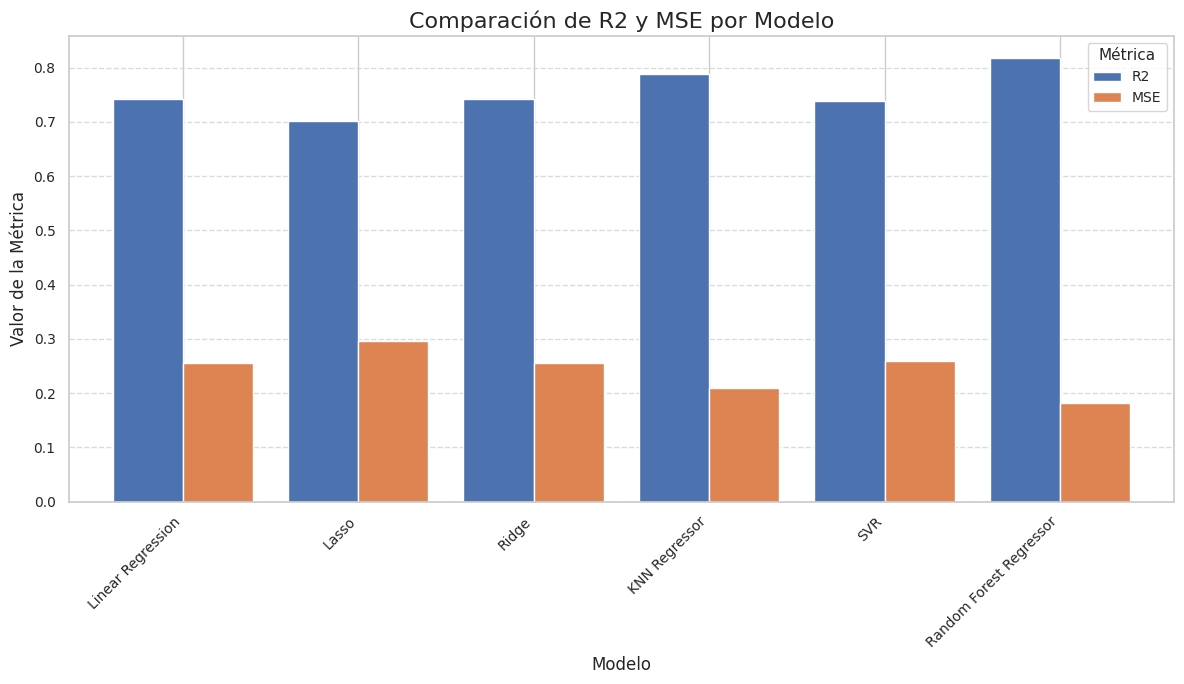

In [264]:
import matplotlib.pyplot as plt
import seaborn as sns

# Seleccionar solo las métricas R2 y MSE para comparar
results_to_plot = results_df[['R2', 'MSE']]

# Crear el gráfico de barras comparativo
fig, ax = plt.subplots(figsize=(12, 7))
results_to_plot.plot(kind='bar', ax=ax, width=0.8)

plt.title('Comparación de R2 y MSE por Modelo', fontsize=16)
plt.ylabel('Valor de la Métrica', fontsize=12)
plt.xlabel('Modelo', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Métrica', fontsize=10, title_fontsize='11')
plt.tight_layout()
plt.show()